# 01 — Data Loading & Exploration

**Goal of this notebook:** understand what we're actually working with before writing a single line of model code.

We're building a detector for a single class (`waldo`) inside dense, cluttered scenes, using a small
dataset (65 raw puzzle-book pages). Two properties of this problem are going to shape every downstream
decision, and we want *evidence* for them, not just the assumption:

1. **Waldo is tiny relative to the scene** — this is a small-object-detection problem, not a general
   object detection problem, and that changes how we choose window sizes, anchor scales, and stride.
2. **The data is heavily class-imbalanced** — almost every region of every image is "not Waldo". If we
   later train a sliding-window classifier, we need to know just how imbalanced this is, because it's
   what will make plain accuracy a useless metric (predicting "not Waldo" everywhere would already score
   ~99%+ accuracy).

We'll also verify a correctness property of the data split itself: since the source dataset augments
each raw scene into 3 copies, we need to confirm none of those copies leak across train/valid/test.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset_utils import build_manifest

plt.rcParams["figure.dpi"] = 110

## Load the raw dataset

`build_manifest()` walks the `train/valid/test` folders the Roboflow export produced and parses every
Pascal VOC `.xml` annotation into one row per image: its split, its image path, and its Waldo box(es)
in absolute pixel coordinates. See `src/data/voc_parser.py` and `src/data/dataset_utils.py`.

In [2]:
manifest = build_manifest()
print(f"{len(manifest)} images total")
manifest.groupby("split").size()

141 images total


split
test       7
train    125
valid      9
dtype: int64

In [3]:
manifest.head()

,split,scene_id,file_stem,image_path,xml_path,width,height,num_boxes,boxes
0,train,10_15_4,10_15_4_jpg.rf.2df611cadb1226890b230a5b4d6d08e3,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(337, 237, 641, 618)]"
1,train,10_15_4,10_15_4_jpg.rf.cf056fa8e03903353f0354f1d53032cd,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(24, 337, 405, 641)]"
2,train,10_7_2,10_7_2_jpg.rf.0b2b099a3c2183708688b4fe3f610bca,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(495, 135, 641, 393)]"
3,train,10_7_2,10_7_2_jpg.rf.6b3706517463681643818c97c32fd567,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(249, 1, 507, 147)]"
4,train,10_7_2,10_7_2_jpg.rf.8de0487c51b95dfea69bdb5a34b4aaba,D:\python_envs\wheres-wally\data\raw\wheres-wa...,D:\python_envs\wheres-wally\data\raw\wheres-wa...,640,640,1,"[(495, 135, 641, 393)]"


## Verify the split doesn't leak across scenes

This dataset's `train` split contains **augmented copies** of the same underlying page (flipped,
rotated) — Roboflow's exported filenames encode this: `10_15_4_jpg.rf.<hash>.jpg` is one of several
copies of raw scene `10_15_4`. `scene_id_from_stem()` strips the `.rf.<hash>` suffix to recover that
shared id.

**Why this matters:** if the *same underlying page* ended up in both `train` and `test` (even as
differently-augmented copies), evaluation on `test` would be measuring memorization of a page the model
effectively already saw, not generalization to a new page. This is exactly the patch-level/scene-level
leakage trap called out in the project brief — we check for it here at the whole-image level, and we'll
have to re-check it at the patch level once we start cropping in notebook 02.

In [4]:
splits_per_scene = manifest.groupby("scene_id")["split"].nunique()
leaking_scenes = splits_per_scene[splits_per_scene > 1]

print(f"{manifest['scene_id'].nunique()} unique raw scenes across {len(manifest)} images")
print(f"Scenes appearing in more than one split: {len(leaking_scenes)}")
assert len(leaking_scenes) == 0, "Data leakage: a scene appears in multiple splits!"

copies_per_scene = manifest.groupby(["scene_id", "split"]).size()
copies_per_scene.groupby("split").describe()

60 unique raw scenes across 141 images
Scenes appearing in more than one split: 0


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,7.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
train,44.0,2.840909,0.369989,2.0,3.0,3.0,3.0,3.0
valid,9.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0


## Look at the actual images

Before computing any statistics, just look at a handful of scenes with their ground-truth boxes drawn
on. This is the fastest way to catch a parsing bug (e.g. swapped x/y, or a box drawn over the wrong
region) before it silently corrupts every downstream stage.

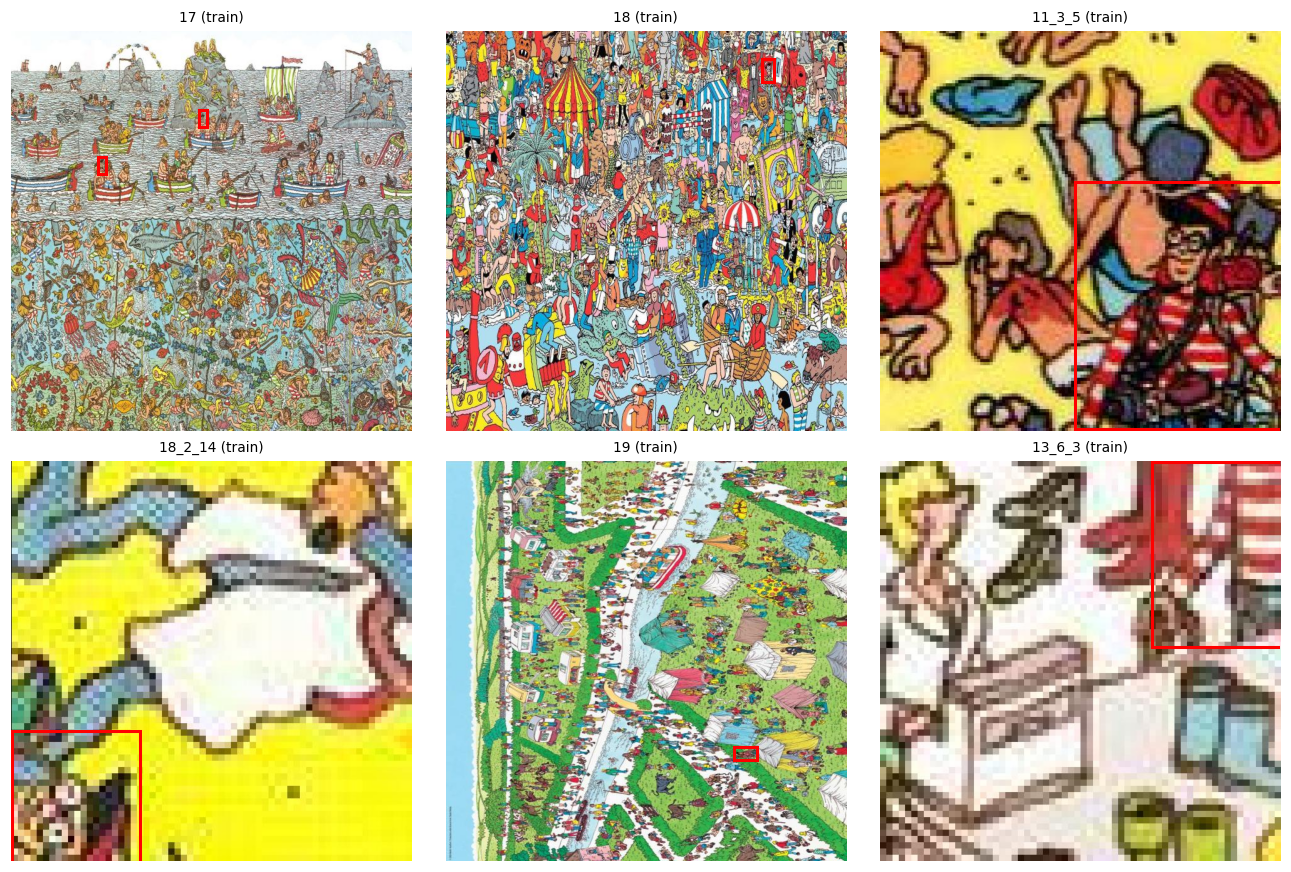

In [5]:
def show_samples(df: pd.DataFrame, n: int = 6, seed: int = 0):
    sample = df.sample(n=n, random_state=seed)
    fig, axes = plt.subplots(2, n // 2, figsize=(4 * (n // 2), 8))
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        img = Image.open(row["image_path"])
        ax.imshow(img)
        for (x1, y1, x2, y2) in row["boxes"]:
            ax.add_patch(
                plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2)
            )
        ax.set_title(f"{row['scene_id']} ({row['split']})", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_samples(manifest, n=6)

## Scene size distribution

Full scanned puzzle pages are large and not a fixed size. This matters for notebook 02: whatever
tiling/stride policy we pick for generating sliding-window patches has to work across this range, not
just for one canonical resolution.

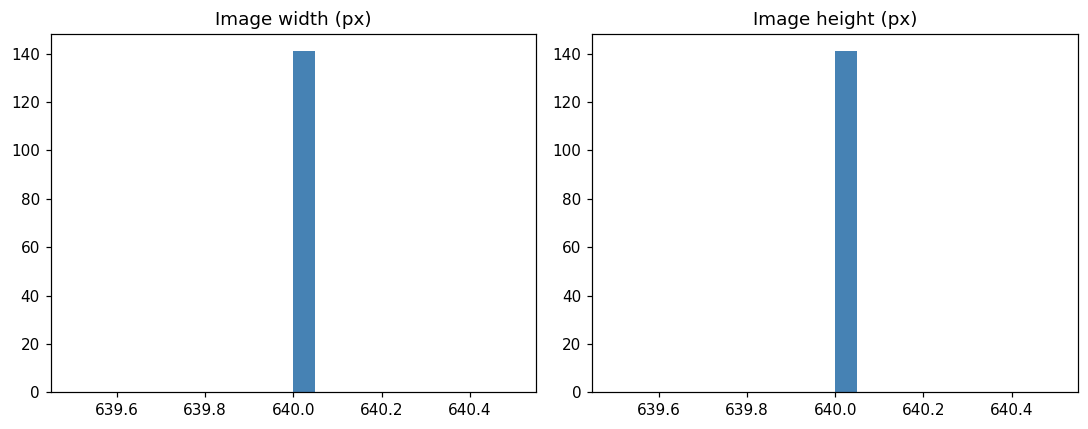

,width,height
count,141.0,141.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(manifest["width"], bins=20, color="steelblue")
axes[0].set_title("Image width (px)")
axes[1].hist(manifest["height"], bins=20, color="steelblue")
axes[1].set_title("Image height (px)")
plt.tight_layout()
plt.show()

manifest[["width", "height"]].describe()

## Waldo bounding box size — quantifying "tiny"

This is the central fact that justifies calling this a *small-object* detection problem rather than a
generic one. We compute, for every Waldo box: its pixel width/height, and — more informatively — its
**area as a fraction of the full scene's area**, since a 40px box means something very different in a
400px image than in a 4000px image.

In [7]:
box_rows = []
for _, row in manifest.iterrows():
    img_area = row["width"] * row["height"]
    for (x1, y1, x2, y2) in row["boxes"]:
        bw, bh = x2 - x1, y2 - y1
        box_rows.append(
            {
                "scene_id": row["scene_id"],
                "split": row["split"],
                "box_w": bw,
                "box_h": bh,
                "box_area": bw * bh,
                "image_area": img_area,
                "area_fraction": (bw * bh) / img_area,
            }
        )

boxes_df = pd.DataFrame(box_rows)
print(f"{len(boxes_df)} Waldo boxes total ({manifest['num_boxes'].eq(0).sum()} images have none)")
boxes_df[["box_w", "box_h", "area_fraction"]].describe()

143 Waldo boxes total (3 images have none)


,box_w,box_h,area_fraction
count,143.000000,143.000000,143.000000
mean,204.587413,233.657343,0.169251
std,172.660104,188.883044,0.202826
min,10.000000,12.000000,0.000537
25%,32.000000,36.000000,0.001758
50%,205.000000,213.000000,0.104602
75%,290.000000,373.000000,0.265039
max,640.000000,640.000000,0.993750


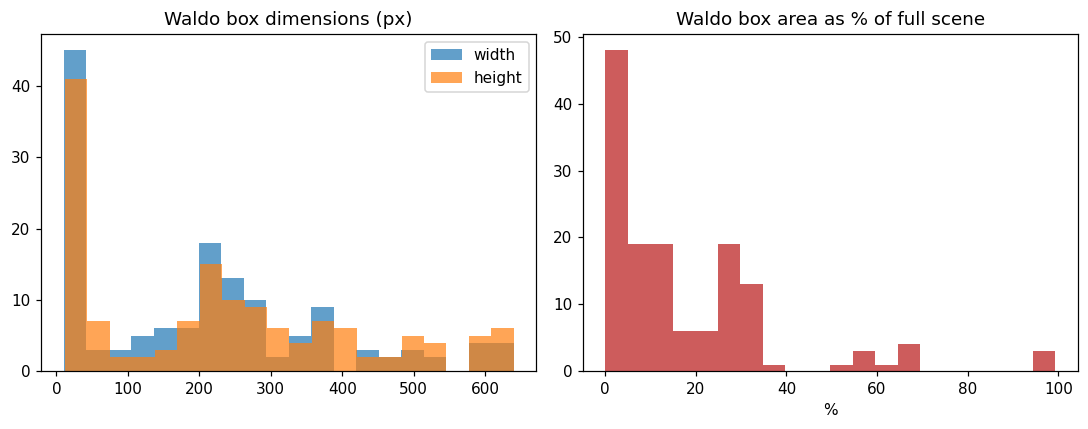

Median Waldo box covers just 10.460% of the scene's pixels.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(boxes_df["box_w"], bins=20, alpha=0.7, label="width")
axes[0].hist(boxes_df["box_h"], bins=20, alpha=0.7, label="height")
axes[0].set_title("Waldo box dimensions (px)")
axes[0].legend()

axes[1].hist(boxes_df["area_fraction"] * 100, bins=20, color="indianred")
axes[1].set_title("Waldo box area as % of full scene")
axes[1].set_xlabel("%")
plt.tight_layout()
plt.show()

median_pct = boxes_df["area_fraction"].median() * 100
print(f"Median Waldo box covers just {median_pct:.3f}% of the scene's pixels.")

## Wait — is this data actually what it claims to be?

The bbox area-fraction spread above is suspicious: a 10% *median* box is nowhere near "tiny", and the
max is 99% (a box covering almost the entire image). That's not what a hidden-in-a-crowd puzzle should
look like. Before building anything on top of this data, let's actually look at the worst offenders.

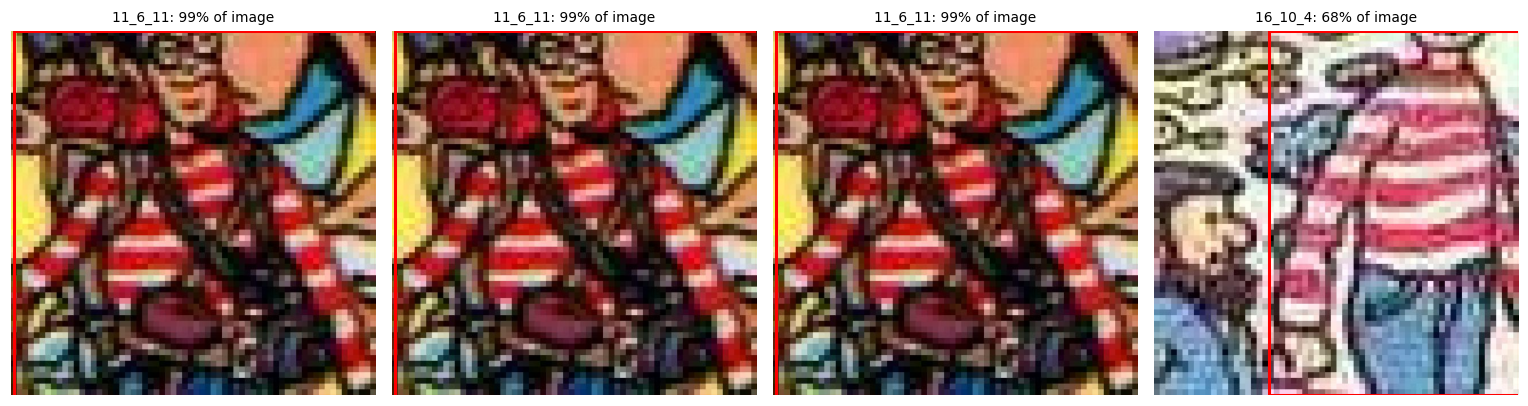

In [9]:
worst = boxes_df.sort_values("area_fraction", ascending=False).head(4)
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (_, row) in zip(axes, worst.iterrows()):
    match = manifest[manifest["scene_id"] == row["scene_id"]].iloc[0]
    img = Image.open(match["image_path"])
    ax.imshow(img)
    for (x1, y1, x2, y2) in match["boxes"]:
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=2))
    ax.set_title(f"{row['scene_id']}: {row['area_fraction']*100:.0f}% of image", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

These aren't hidden-in-a-crowd puzzle scenes at all — they're close-up portrait crops of a character's
face filling most of the frame. This dataset (a community upload on Roboflow with no description) turns
out to be a merge of two different sources with very different annotation styles. That's visible directly
in the *filenames*: the per-scene id recovered by `scene_id_from_stem()` is either a short integer
(`"1"`, `"2"`, ... `"19"`) or a compound id (`"9_2_2"`, `"13_1_5"`, ...). Let's check whether that id
pattern lines up with the area-fraction split.

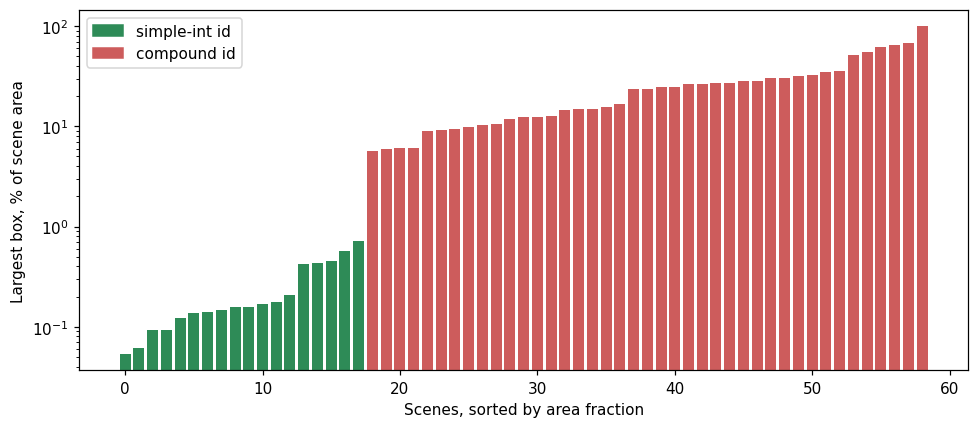

                         count      mean       std       min       25%  \
id_style                                                                 
compound (e.g. '9_2_2')   41.0  0.259703  0.201976  0.057334  0.118337   
simple int (e.g. '7')     18.0  0.002383  0.001907  0.000537  0.001250   

                              50%       75%       max  
id_style                                               
compound (e.g. '9_2_2')  0.235156  0.304731  0.993750  
simple int (e.g. '7')    0.001583  0.003680  0.007107  


In [10]:
scene_max_frac = (
    boxes_df.groupby("scene_id")["area_fraction"].max().sort_values().reset_index()
)
scene_max_frac["id_style"] = scene_max_frac["scene_id"].apply(
    lambda s: "simple int (e.g. '7')" if s.isdigit() else "compound (e.g. '9_2_2')"
)

fig, ax = plt.subplots(figsize=(9, 4))
colors = scene_max_frac["id_style"].map(
    {"simple int (e.g. '7')": "seagreen", "compound (e.g. '9_2_2')": "indianred"}
)
ax.bar(range(len(scene_max_frac)), scene_max_frac["area_fraction"] * 100, color=colors)
ax.set_ylabel("Largest box, % of scene area")
ax.set_xlabel("Scenes, sorted by area fraction")
ax.set_yscale("log")
handles = [
    plt.Rectangle((0, 0), 1, 1, color="seagreen", label="simple-int id"),
    plt.Rectangle((0, 0), 1, 1, color="indianred", label="compound id"),
]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

print(scene_max_frac.groupby("id_style")["area_fraction"].describe())

The id pattern lines up perfectly with a huge natural gap in the data: every "simple integer" scene has
its largest box under ~1% of the image, and every "compound id" scene is at 5.7% or above — there is
nothing in between. All 19 simple-integer scenes (`1`...`19`) are genuinely tiny, tightly-annotated
Waldo boxes; the other 41 (compound-id) scenes are the portrait closeups. 19 also happens to match the
scene count of the well-known [Hey-Waldo](https://github.com/vc1492a/Hey-Waldo) dataset, so this is most
likely Hey-Waldo's 19 original puzzle-book scans with bounding boxes added by whoever built this Roboflow
project, merged with a second, much lower-quality batch of images from somewhere else.

**Decision:** keep only the 19 simple-integer scenes. They're the only ones that match this project's
actual premise (localizing a tiny figure in visual clutter) — training or evaluating on the portrait
closeups would teach and measure a materially easier, different task. This does shrink the usable
dataset from 65 to 19 raw scenes, which pushes the "low-data regime" the project brief already expects
to its extreme end. The practical consequence for notebook 02 onward: a single fixed train/val/test
split would leave only 1-2 scenes for test, which is too small to trust — we'll use scene-level k-fold
cross-validation instead of one fixed split, and lean harder on augmentation and patch-level sampling to
get usable training signal out of so few source images.

In [11]:
clean_scene_ids = [str(i) for i in range(1, 20)]

# Each clean scene has 1-3 copies from Roboflow's own train/valid/test split (the
# valid/test ones are single, unaugmented copies; several train ones have 3
# Roboflow-augmented copies). We only want ONE canonical image per scene: which
# specific copy we pick doesn't matter much since we'll run our own augmentation
# pipeline in notebook 02 regardless, so we just take the first copy per scene.
clean = manifest[manifest["scene_id"].isin(clean_scene_ids)].copy()
clean_manifest = (
    clean.sort_values("file_stem").groupby("scene_id", as_index=False).first()
)
clean_manifest = clean_manifest.sort_values(by="scene_id", key=lambda s: s.astype(int)).reset_index(drop=True)

print(f"Clean manifest: {len(clean_manifest)} scenes (was {manifest['scene_id'].nunique()} raw scenes)")
clean_manifest[["scene_id", "split", "width", "height", "num_boxes"]]

Clean manifest: 19 scenes (was 60 raw scenes)


,scene_id,split,width,height,num_boxes
0,1,train,640,640,1
1,2,train,640,640,1
2,3,train,640,640,1
3,4,valid,640,640,1
4,5,train,640,640,1
5,6,test,640,640,1
6,7,train,640,640,1
7,8,valid,640,640,2
8,9,train,640,640,1
9,10,valid,640,640,2


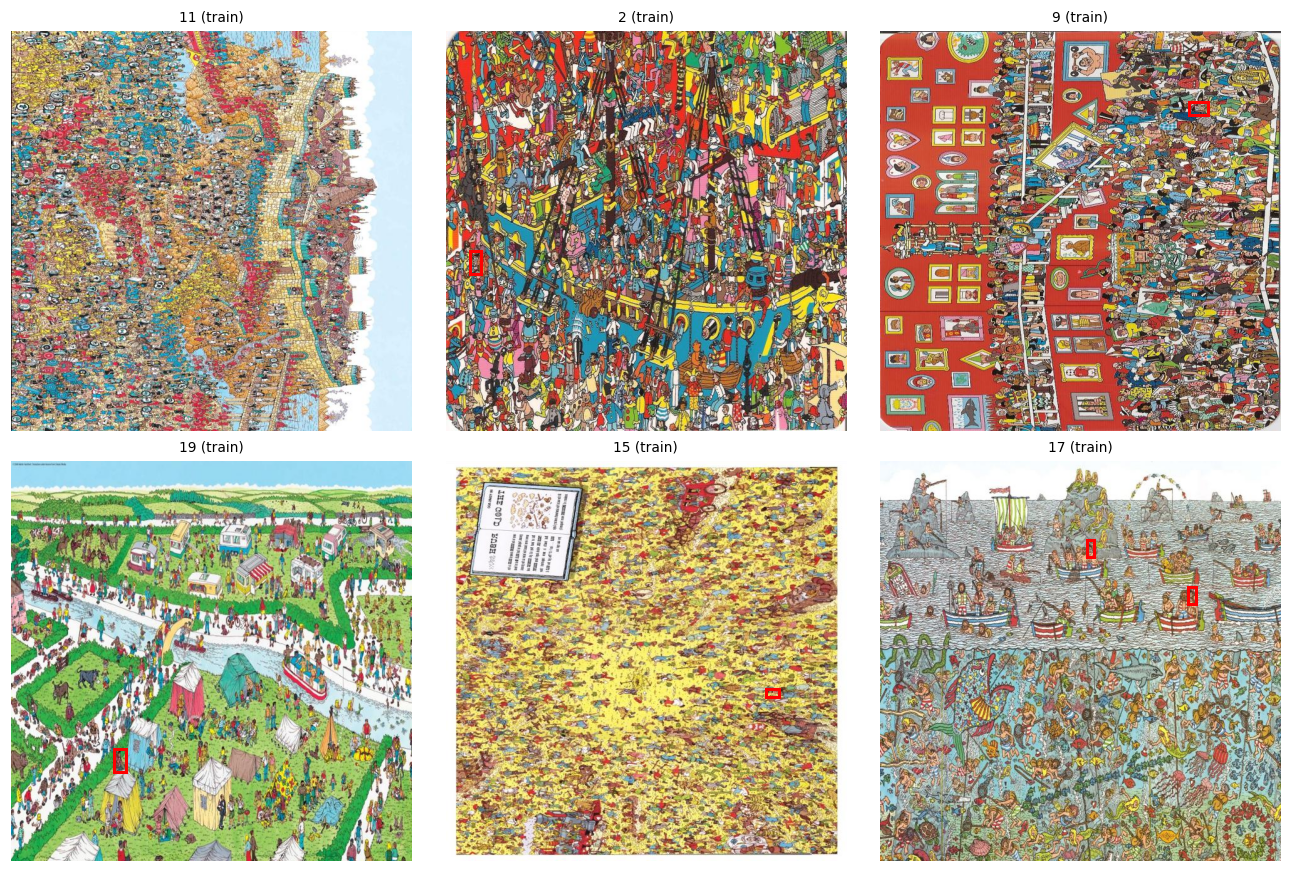

In [12]:
show_samples(clean_manifest, n=6)

In [13]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

manifest_to_save = clean_manifest.drop(columns=["boxes"]).copy()
manifest_to_save["boxes"] = clean_manifest["boxes"].apply(str)  # store as a literal list string
manifest_to_save.to_csv(PROCESSED_DIR / "clean_manifest.csv", index=False)
print(f"Saved {len(manifest_to_save)}-row clean manifest to {PROCESSED_DIR / 'clean_manifest.csv'}")

Saved 19-row clean manifest to D:\python_envs\wheres-wally\data\processed\clean_manifest.csv


## Re-measuring "tiny" and class imbalance on the clean data

The box-size and imbalance numbers earlier in this notebook were computed on the *contaminated* full
manifest, so they're not trustworthy — the portrait closeups pulled the median box size way up. Let's
redo both measurements on `clean_manifest` only.

In [14]:
clean_box_rows = []
for _, row in clean_manifest.iterrows():
    img_area = row["width"] * row["height"]
    for (x1, y1, x2, y2) in row["boxes"]:
        bw, bh = x2 - x1, y2 - y1
        clean_box_rows.append(
            {"scene_id": row["scene_id"], "box_w": bw, "box_h": bh, "area_fraction": (bw * bh) / img_area}
        )

clean_boxes_df = pd.DataFrame(clean_box_rows)
clean_median_pct = clean_boxes_df["area_fraction"].median() * 100
print(f"Clean-data median Waldo box covers {clean_median_pct:.3f}% of the scene — genuinely tiny.")
clean_boxes_df[["box_w", "box_h", "area_fraction"]].describe()

Clean-data median Waldo box covers 0.143% of the scene — genuinely tiny.


,box_w,box_h,area_fraction
count,21.000000,21.00000,21.000000
mean,23.714286,35.00000,0.002164
std,15.424470,13.28533,0.001841
min,10.000000,12.00000,0.000537
25%,15.000000,28.00000,0.000937
50%,19.000000,33.00000,0.001428
75%,30.000000,38.00000,0.002065
max,70.000000,71.00000,0.007107


In [15]:
from src.eval.box_utils import iou

median_w = int(clean_boxes_df["box_w"].median())
median_h = int(clean_boxes_df["box_h"].median())
stride = max(1, median_w // 2)

sample_row = clean_manifest.sample(1, random_state=1).iloc[0]
W, H = sample_row["width"], sample_row["height"]
gt_boxes = sample_row["boxes"]

total_windows = 0
positive_windows = 0
for y in range(0, H - median_h, stride):
    for x in range(0, W - median_w, stride):
        window = (x, y, x + median_w, y + median_h)
        total_windows += 1
        if any(iou(np.array(window), np.array(gt)) > 0.3 for gt in gt_boxes):
            positive_windows += 1

negative_windows = total_windows - positive_windows
print(f"Scene {sample_row['scene_id']}: {W}x{H}, window {median_w}x{median_h}, stride {stride}")
print(f"Total windows:    {total_windows}")
print(f"Positive windows: {positive_windows}")
print(f"Negative windows: {negative_windows}")
print(f"Positive:negative ratio ≈ 1:{negative_windows / max(1, positive_windows):.0f}")

Scene 4: 640x640, window 19x33, stride 9
Total windows:    4692
Positive windows: 2
Negative windows: 4690
Positive:negative ratio ≈ 1:2345


One more thing worth flagging before moving on: `clean_manifest` shows scene `11` has **zero** annotated
boxes, and scenes `8`, `10`, `17` have **two** each. We're not treating these as bugs to fix — they're
real properties of the source annotations to carry forward honestly: scene 11 can still contribute
negative patches (it just contributes no positive ones), and the multi-box scenes likely have a
Waldo-lookalike or a genuine duplicate annotation. Notebook 02's patch generation needs to handle
`num_boxes == 0` without erroring (no positive patches from that scene) and `num_boxes > 1` correctly
(treat each box independently, don't assume exactly one).

## Takeaways → what this motivates for notebook 02

- **The raw dataset needed cleaning before it could be trusted.** ~63% of the 60 raw scenes turned out
  to be portrait closeups, not hidden-in-a-crowd puzzles — found by noticing the bbox area-fraction
  distribution was implausible for "tiny", then tracing it to a natural gap that lines up exactly with
  a filename pattern. Only the 19 simple-integer-id scenes are genuine, and we now build everything else
  on `data/processed/clean_manifest.csv`, not the raw Roboflow export.
- **No scene-level leakage** in the original split — confirmed above, though moot now since we're
  moving to our own cross-validation split over the 19 clean scenes rather than reusing Roboflow's.
- **Waldo boxes really are tiny once the data is clean** (median well under 1% of the scene, vs. the
  misleading 10.5% the contaminated data showed) — this rules out treating the whole scene as one
  classification example, and justifies the sliding-window / tiling approach: we need to look at small
  local crops, not the whole page.
- **Extreme class imbalance** confirmed on clean data too — this means:
  1. We cannot just generate *all* windows as training data — we need explicit **negative mining**
     (sampling a manageable, still-informative subset of negatives, including hard negatives near but
     not on Waldo) rather than exhaustively enumerating every window.
  2. Plain accuracy will be a misleading metric for the patch classifier — precision/recall (and later,
     detection metrics like precision/recall @ IoU) are what we'll actually track.
  3. Aggressive augmentation of the rare positive class (crops, flips, color jitter, scale jitter) is
     essential given how few real positive examples now exist (19 raw scenes, down from the 65
     originally expected).
- **19 scenes is too few for one fixed train/val/test split** — notebook 02 will use scene-level k-fold
  cross-validation instead, so every scene gets to be in a test fold exactly once despite the small
  total count, and patch generation/augmentation happens *within* each fold's train scenes only, to
  avoid the patch-level leakage flagged above.

Notebook 02 builds the k-fold splitting + tiling + patch-generation + augmentation pipeline directly on
these findings.